## 1. Setup & Imports
All third-party imports, device selection, and global random seed.

In [ ]:
import os, math, random
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from scipy.spatial.distance import pdist, squareform
from sklearn import linear_model
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Configuration
All hyperparameters and paths in one place, change here only.

In [ ]:
cfg = SimpleNamespace(
    # --- Paths ---
    dataset_dir="/kaggle/input/competitions/csiro-biomass",
    dino_weights_dir="/kaggle/input/datasets/darealvictorslorer/dinov2-small-weights/dinov2-small",
    output_dir="/kaggle/working",
    # --- Model ---
    input_dim=384,
    latent_dim=64,
    output_dim=5,
    dropout=0.3,
    # --- CEMS ---
    sigma=1e-3, # used when sigma_auto=False
    sigma_auto=True, # True -> derive sigma from median NN distance in z-space
    sigma_fraction=0.1, # sigma = median_nn_dist * sigma_fraction (only when sigma_auto=True)
    sigma_dedup=True, # True -> use one variant per image for NN distance; False -> use all augmented samples
    mix_real=False, # True -> loss = loss_real + lambda_aug * loss_aug; False -> loss_aug only
    lambda_aug=1.0, # weight on augmented loss term (used when mix_real=True)
    neigh_type="random", # batch formation: "random" | "knn" | "knnp"
    # --- Orientation Augmentation ---
    # Subset of ["identity", "hflip", "vflip", "hflip_vflip"]; must include "identity"
    augmentations=["identity", "hflip", "vflip", "hflip_vflip"],
    # --- Training ---
    epochs=80,
    lr=3e-4,
    weight_decay=1e-3,
    seed=42,
    batch_size=32,
    # --- Split ---
    n_splits=5,
    val_fold=0,
)

TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
           "GDM_g": 0.2, "Dry_Total_g": 0.5}

TRAIN_CSV = os.path.join(cfg.dataset_dir, "train.csv")
TEST_CSV = os.path.join(cfg.dataset_dir, "test.csv")
TRAIN_IMG_DIR = os.path.join(cfg.dataset_dir, "train")
TEST_IMG_DIR = os.path.join(cfg.dataset_dir, "test")

print("train.csv:", os.path.exists(TRAIN_CSV))
print("test.csv:", os.path.exists(TEST_CSV))
print("train dir:", os.path.exists(TRAIN_IMG_DIR))
print("test dir:", os.path.exists(TEST_IMG_DIR))
print("dino dir:", os.path.exists(cfg.dino_weights_dir))

## 3. Load DINOv2
Load ViT-S/14 from uploaded HuggingFace weights; smoke-test at 504×252 resolution.

In [ ]:
print(f"Loading DINOv2-small from {cfg.dino_weights_dir} ...")
dino = AutoModel.from_pretrained(cfg.dino_weights_dir).eval().to(device)
for p in dino.parameters():
    p.requires_grad_(False)

# Smoke test: 504x252 input (W=504, H=252) - must pass interpolate_pos_encoding=True
# because this is a non-standard resolution for the HF wrapper.
_dummy = torch.zeros(1, 3, 252, 504, device=device) # (B, C, H, W)
with torch.no_grad():
    _out = dino(pixel_values=_dummy, interpolate_pos_encoding=True)
    _cls = _out.last_hidden_state[:, 0, :]  # CLS token
assert _cls.shape == (1, 384), f"Expected (1, 384), got {_cls.shape}"
print(f"DINOv2 smoke test passed - CLS shape: {_cls.shape}")
del _dummy, _out, _cls

Loading DINOv2-small from /kaggle/input/datasets/darealvictorslorer/dinov2-small-weights/dinov2-small ...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 smoke test passed — CLS shape: torch.Size([1, 384])


## 4. Load Training CSV
Pivot long-format CSV to wide format (one row per image) and extract Y matrix.

In [4]:
df_raw = pd.read_csv(TRAIN_CSV)
df_raw["image_id"] = df_raw["sample_id"].str.split("__").str[0]

df_wide = df_raw.pivot_table(
    index=["image_id", "image_path"],
    columns="target_name",
    values="target",
).reset_index()

Y_all = df_wide[TARGETS].values.astype(np.float32)  # (N, 5)
train_image_ids_all = df_wide["image_id"].values

print(f"Training images: {len(df_wide)}")
print(f"Y_all shape: {Y_all.shape}")
print(df_wide.head(3))

Training images: 357
Y_all shape: (357, 5)
target_name      image_id              image_path  Dry_Clover_g  Dry_Dead_g  \
0            ID1011485656  train/ID1011485656.jpg          0.00     31.9984   
1            ID1012260530  train/ID1012260530.jpg          0.00      0.0000   
2            ID1025234388  train/ID1025234388.jpg          6.05      0.0000   

target_name  Dry_Green_g  Dry_Total_g   GDM_g  
0                16.2751      48.2735  16.275  
1                 7.6000       7.6000   7.600  
2                 0.0000       6.0500   6.050  


## 5. Extract DINOv2 Features - Training Images
Preprocess at 504×252 and extract CLS tokens with configurable augmentations (identity, hflip, vflip, hflip+vflip).

In [ ]:
# 504x252 = (W x H); torchvision Resize takes (H, W) = (252, 504)
_dino_transform = T.Compose([
    T.Resize((252, 504)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_features(image_paths, model, transform):
    """Return (N, 384) float32 array of CLS-token features."""
    feats = []
    for i, p in enumerate(image_paths):
        img = Image.open(p).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(pixel_values=x, interpolate_pos_encoding=True)
            feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
        feats.append(feat)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(image_paths)}")
    return np.stack(feats).astype(np.float32)


_AUGMENTATION_FNS = {
    "identity": lambda img: img,
    "hflip": lambda img: TF.hflip(img),
    "vflip": lambda img: TF.vflip(img),
    "hflip_vflip": lambda img: TF.hflip(TF.vflip(img)),
}
_ORIENTATIONS = [_AUGMENTATION_FNS[a] for a in cfg.augmentations]
n_aug = len(_ORIENTATIONS)


def extract_features_augmented(image_paths, model, transform):
    """Return (N*n_aug, 384) array - each image appears n_aug times."""
    feats = []
    for i, p in enumerate(image_paths):
        img = Image.open(p).convert("RGB")
        for flip_fn in _ORIENTATIONS:
            x = transform(flip_fn(img)).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(pixel_values=x, interpolate_pos_encoding=True)
                feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
            feats.append(feat)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(image_paths)}")
    return np.stack(feats).astype(np.float32)


train_image_paths = [
    os.path.join(TRAIN_IMG_DIR, f"{iid}.jpg")
    for iid in train_image_ids_all
]
N_orig = len(train_image_paths)
print(f"Extracting features for {N_orig} training images ({n_aug} orientations each)...")
X_all = extract_features_augmented(train_image_paths, dino, _dino_transform)

# Expand Y and image IDs to match augmented feature array
Y_all = np.repeat(Y_all, n_aug, axis=0)
train_image_ids_all = np.repeat(train_image_ids_all, n_aug)
image_group_ids = np.repeat(np.arange(N_orig), n_aug)

print(f"X_all shape: {X_all.shape}")
print(f"Y_all shape: {Y_all.shape}")
print(f"image_group_ids len: {len(image_group_ids)}")
print(f"Unique groups: {len(np.unique(image_group_ids))}")

# Sanity checks
assert X_all.shape == (N_orig * n_aug, 384), f"Expected ({N_orig*n_aug}, 384), got {X_all.shape}"
assert Y_all.shape == (N_orig * n_aug, 5)
assert len(image_group_ids) == N_orig * n_aug
assert len(np.unique(image_group_ids)) == N_orig
assert np.all(np.bincount(image_group_ids) == n_aug), "Each group must appear exactly n_aug times"
print("Sanity checks passed.")

Extracting features for 357 training images (4 orientations each)...
  50/357
  100/357
  150/357
  200/357
  250/357
  300/357
  350/357
X_all shape: (1428, 384)
Y_all shape: (1428, 5)
image_group_ids len: 1428
Unique groups: 357
Sanity checks passed.


## 6. Extract DINOv2 Features - Test Image
Same preprocessing pipeline applied to the held-out test set.

In [6]:
df_test_raw = pd.read_csv(TEST_CSV)
df_test_raw["image_id"] = df_test_raw["sample_id"].str.split("__").str[0]
df_test_unique = df_test_raw.drop_duplicates("image_id").copy()

test_image_ids = df_test_unique["image_id"].values
test_image_paths = [
    os.path.join(TEST_IMG_DIR, f"{iid}.jpg")
    for iid in test_image_ids
]

print(f"Extracting features for {len(test_image_paths)} test images...")
X_test = extract_features(test_image_paths, dino, _dino_transform)
print(f"X_test shape: {X_test.shape}")

Extracting features for 1 test images...
X_test shape: (1, 384)


## 7. GroupKFold Train/Val Split
Fold 0 of a 5-fold GroupKFold. Grouped by original image index so all 4 orientations of one image land in the same fold and prevents augmented-twin leakage.

In [ ]:
gkf = GroupKFold(n_splits=cfg.n_splits)
# Group by original image index so all 4 orientations of an image land in the same fold
splits = list(gkf.split(X_all, groups=image_group_ids))
train_idx, val_idx = splits[cfg.val_fold]

X_train = X_all[train_idx]
Y_train_raw = Y_all[train_idx]
X_val = X_all[val_idx]
Y_val_raw = Y_all[val_idx]
train_ids_split = train_image_ids_all[train_idx]
val_ids_split = train_image_ids_all[val_idx]

# Sanity check: no original image shared across train and val
train_groups = set(image_group_ids[train_idx].tolist())
val_groups = set(image_group_ids[val_idx].tolist())
assert train_groups.isdisjoint(val_groups), "Group leakage: original images shared across folds!"
print("Group overlap check: PASSED (zero overlap)")

print(f"Train: {X_train.shape}  Val: {X_val.shape}")
print(f"Y_train range: [{Y_train_raw.min():.1f}, {Y_train_raw.max():.1f}]")

Group overlap check: PASSED (zero overlap)
Train: (1140, 384)  Val: (288, 384)
Y_train range: [0.0, 185.7]


## 8. MinMaxScaler on Y_train
Fit scaler on training labels only; used inside CEMS joint space for label normalisation.

In [8]:
y_scaler = MinMaxScaler()
y_scaler.fit(Y_train_raw)
Y_train_scaled = y_scaler.transform(Y_train_raw).astype(np.float32)

print(f"Y_train_scaled range: [{Y_train_scaled.min():.3f}, {Y_train_scaled.max():.3f}]")
print("Scaler data_min_:", y_scaler.data_min_.round(2))
print("Scaler data_max_:", y_scaler.data_max_.round(2))

Y_train_scaled range: [0.000, 1.000]
Scaler data_min_: [0.   0.   0.   1.4  2.48]
Scaler data_max_: [157.98  83.84  71.79 157.98 185.7 ]


## 9. Model Architecture - Encoder, Head, BiomassModel
Encoder 384→256→64 (GELU, Dropout), Head 64→32→5 (GELU, no dropout).

In [ ]:
class Encoder(nn.Module):
    """384 → 256 → 64 (GELU, Dropout)."""

    def __init__(self, input_dim=384, latent_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class Head(nn.Module):
    """64 → 32 → 5 (GELU, Dropout)."""

    def __init__(self, latent_dim=64, output_dim=5, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, output_dim),
        )

    def forward(self, z):
        return self.net(z)


class BiomassModel(nn.Module):

    def __init__(self, input_dim=384, latent_dim=64, output_dim=5, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim, dropout)
        self.head = Head(latent_dim, output_dim, dropout)

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.head(self.encode(x))


print("BiomassModel defined.")
# Quick parameter count
_tmp = BiomassModel(cfg.input_dim, cfg.latent_dim, cfg.output_dim, cfg.dropout)
n_params = sum(p.numel() for p in _tmp.parameters())
print(f"Parameters: {n_params:,}")
del _tmp

## 10. CEMS Algorithm
Functions ported from `src/cems.py` and `src/intrinsic_dimension.py`, see https://github.com/azencot-group/CEMS/tree/main for source code. See per-function source comments for exact origin and deviations.

| Function | Origin | Status |
|---|---|---|
| `_estimate_np` | `intrinsic_dimension.py::estimate_np` | copied; verbose stripped |
| `intrinsic_dimension` | `intrinsic_dimension.py::intrinsic_dimension_np` | based on; numpy-only path |
| `_adjust_dims` | `cems.py::_adjust_dims` | based on; xk/yk params and zk removed; type annotations stripped |
| `_get_projection` | `cems.py::_get_projection` | based on; SVD driver conditional on CUDA; cems_method=2 branch removed; xk param removed |
| `_solve_ridge_regression` | `cems.py::_solve_ridge_regression` | copied; no changes |
| `_estimate_grad_hessian` | `cems.py::_estimate_grad_hessian` | based on; xk param removed; triu_indices gets device= |
| `_sample_tangent` | `cems.py::_sample_tangent` | based on; cems_method=2 branch removed |
| `get_batch_cems` | `cems.py::get_batch_cems` | based on; xk/yk removed; numpy ID path; finite/range fallback; scaler removed |

In [ ]:
# ---------------------------------------------------------------------------
# TwoNN intrinsic dimension estimator (Facco et al. 2017)
# ---------------------------------------------------------------------------

# Copied from src/intrinsic_dimension.py::estimate_np
# Change: removed verbose parameter and associated print statements
def _estimate_np(X, fraction=0.9):
    """TwoNN slope estimator on a precomputed (n, n) distance matrix."""
    Y = np.sort(X, axis=1, kind='quicksort')
    k1 = Y[:, 1]
    k2 = Y[:, 2]

    zeros        = np.where(k1 == 0)[0]
    degeneracies = np.where(k1 == k2)[0]
    good = np.setdiff1d(np.arange(Y.shape[0]), zeros)
    good = np.setdiff1d(good, degeneracies)

    k1 = k1[good]
    k2 = k2[good]

    npoints = int(np.floor(good.shape[0] * fraction))
    N = good.shape[0]
    mu = np.sort(np.divide(k2, k1), kind='quicksort')
    Femp = np.arange(1, N + 1, dtype=np.float64) / N

    x = np.log(mu[:-2])
    y = -np.log(1 - Femp[:-2])

    regr = linear_model.LinearRegression(fit_intercept=False)
    regr.fit(x[:npoints, np.newaxis], y[:npoints, np.newaxis])
    return regr.coef_[0][0]


# Based on src/intrinsic_dimension.py::intrinsic_dimension_np
# Change: simplified to numpy-only path
def intrinsic_dimension(X):
    """TwoNN intrinsic dimension estimate (Facco et al. 2017). Returns float."""
    dist = squareform(pdist(X, metric='euclidean'))
    return _estimate_np(dist)


# ---------------------------------------------------------------------------
# Step 1 - flatten + form joint space zi = [x | y]
# ---------------------------------------------------------------------------

# Based on src/cems.py::_adjust_dims
# Changes: xk/yk params and zk removed (method 2 dropped); type annotations stripped
def _adjust_dims(x, y):
    if x.ndim > 2:
        x = x.reshape(x.shape[0], -1)
    if y.ndim == 1:
        y = y.reshape(y.shape[0], 1)
    m = x.shape[-1]
    zi = torch.cat((x, y), dim=-1)
    return x, zi, m


# ---------------------------------------------------------------------------
# Step 2 - SVD local orthonormal basis
# ---------------------------------------------------------------------------

# Based on src/cems.py::_get_projection
# Changes: driver="gesvd" made conditional on CUDA to support CPU execution
#          (original passes driver="gesvd" unconditionally, which fails on CPU);
#          cems_method=2 branch removed; xk param removed
def _get_projection(args, x):
    x_c = x.transpose(-2, -1)
    x_c_mean = torch.mean(x_c, -1)
    x_c = x_c - x_c_mean.unsqueeze(-1)

    svd_kwargs = {"driver": "gesvd"} if x_c.is_cuda else {}
    basis, _, _ = torch.linalg.svd(x_c, full_matrices=False, **svd_kwargs)

    u = basis.transpose(-2, -1) @ x_c
    u_prev = u.transpose(-2, -1)

    u_t = u.transpose(-1, -2)
    u = (u_t.unsqueeze(1) - u_t).transpose(-1, -2)
    n = x.shape[0]
    mask = ~torch.eye(n, dtype=torch.bool, device=x.device)
    u = -u.transpose(-1, -2)[mask].reshape((u.shape[0], u.shape[2] - 1, u.shape[1])).transpose(-1, -2)

    return basis, u, u_prev, x_c_mean


# ---------------------------------------------------------------------------
# Ridge regression solver
# ---------------------------------------------------------------------------

# Copied from src/cems.py::_solve_ridge_regression
# Change: nothing
def _solve_ridge_regression(a, b, lam=1.0):
    n = a.shape[-1]
    eye = torch.eye(n, device=a.device, dtype=a.dtype)
    a_t = a.transpose(-2, -1)
    a_reg = a_t @ a + lam * eye
    return torch.linalg.inv(a_reg) @ a_t @ b


# ---------------------------------------------------------------------------
# Steps 3-4 - local gradient and Hessian via ridge regression
# ---------------------------------------------------------------------------

# Based on src/cems.py::_estimate_grad_hessian
# Changes: xk param removed (method 2 dropped);
#          triu_indices gets device=x.device (original has no device arg, fails on CUDA)
def _estimate_grad_hessian(args, x, d):
    tidx = torch.triu_indices(d, d, device=x.device)
    ones_mult = torch.ones((d, d), device=x.device)
    ones_mult.fill_diagonal_(0.5)

    basis, u, u_prev, x_mean = _get_projection(args, x)

    u_d = u[:, :d]
    f = u[:, d:].transpose(-2, -1)

    uu = torch.einsum('bki,bkj->bkij', u_d.transpose(-2, -1), u_d.transpose(-2, -1))
    uu = uu * ones_mult
    uu = uu[:, :, tidx[0], tidx[1]].transpose(-2, -1)
    psi = torch.cat((u_d, uu), dim=1).transpose(-2, -1)

    lam = torch.linalg.norm(psi, dim=(-1, -2)).mean()
    b = _solve_ridge_regression(psi, f, lam=lam).transpose(-2, -1)

    gradient = b[..., :d]
    hessian = torch.zeros(
        (u.shape[0], b.shape[1], d, d), dtype=b.dtype, device=b.device
    )
    hessian[..., tidx[0], tidx[1]] = b[..., d:]
    hessian[..., tidx[1], tidx[0]] = b[..., d:]

    return basis, gradient, hessian, u_d, u_prev, x_mean


# ---------------------------------------------------------------------------
# Step 5 - sample in tangent bundle, project back to ambient space
# ---------------------------------------------------------------------------

# Based on src/cems.py::_sample_tangent
# Change: cems_method=2 branch removed
def _sample_tangent(args, x, u_k_d, u_prev, x_mean, basis, grad, hess):
    d = grad.shape[-1]
    nu = torch.distributions.Normal(0, args.sigma).sample(
        (x.shape[0], d, 1)
    ).to(x.device)

    f_nu = (grad @ nu).squeeze(-1)

    nu_ex = nu.unsqueeze(1)
    f_nu += 0.5 * (nu_ex.transpose(-1, -2) @ hess @ nu_ex).squeeze((-1, -2))

    x_zero = nu.squeeze(-1)
    x_new_local = torch.cat((x_zero, f_nu), dim=-1)
    x_new_local += u_prev

    x_cems = (basis @ x_new_local.unsqueeze(-1)).squeeze(-1)
    x_cems += x_mean
    return x_cems


# ---------------------------------------------------------------------------
# Public entry - get_batch_cems
# ---------------------------------------------------------------------------

# Based on src/cems.py::get_batch_cems
# Changes: xk/yk params removed (method 2 dropped); scaler removed;
#          numpy ID estimation via intrinsic_dimension();
#          finite/range guard with fallback to args.id when estimate is degenerate
def get_batch_cems(args, x, y, *, latent=False):
    """CEMS augmentation for one minibatch. Returns (x_new, y_new)."""
    x_shape, y_shape = x.shape, y.shape
    x_flat, zi, m = _adjust_dims(x, y)

    d = args.id
    if latent:
        _d = intrinsic_dimension(zi.detach().cpu().numpy())
        d = max(1, int(round(_d))) if math.isfinite(_d) and _d >= 1 else args.id

    if d < 1 or d >= zi.shape[-1] or d >= zi.shape[-2]:
        d = min(args.id, zi.shape[-1] - 1, zi.shape[-2] - 1)

    basis, grad, hess, u_k_d, u_prev, x_mean = _estimate_grad_hessian(args, zi, d)
    z_sampled = _sample_tangent(args, zi, u_k_d, u_prev, x_mean, basis, grad, hess)

    x_new = z_sampled[..., :m].reshape(x_shape)
    y_new = z_sampled[..., m:].reshape(y_shape)
    return x_new, y_new


print("CEMS functions defined.")

## 11. Training Setup Utilities
`build_group_index`, `calibrate_sigma`, and `precompute_knn` are new utilities not present in the original source code.

| Function | Origin | Status |
|---|---|---|
| `build_group_index` | not in original | new |
| `calibrate_sigma` | not in original | new |
| `precompute_knn` | mirrors `cems_utils.py::get_probabilities` (knn/knnp branches) | new; adapted for [X, Y_scaled] joint space; returns `None` for `neigh_type='random'` |

In [ ]:
# Not in original CEMS-main
def build_group_index(group_ids):
    """Map each unique group ID to its row indices in the dataset split."""
    unique = np.unique(group_ids)
    idx_map = {int(g): np.where(group_ids == g)[0].tolist() for g in unique}
    return unique, len(unique), idx_map


# Not in original CEMS-main
def calibrate_sigma(z_full, cfg, unique_groups, image_id_to_indices, device):
    """Derive sigma from median NN distance in joint z-space, or return cfg.sigma if sigma_auto=False."""
    if not cfg.sigma_auto:
        print(f"sigma fixed: {cfg.sigma}")
        return cfg.sigma
    if cfg.sigma_dedup:
        rep_idx = np.array([image_id_to_indices[int(g)][0] for g in unique_groups])
        z_for_sigma = z_full[rep_idx]
    else:
        z_for_sigma = z_full
    with torch.no_grad():
        nn_dists = torch.cdist(z_for_sigma, z_for_sigma).topk(2, largest=False).values[:, 1]
        median_nn_dist = torch.median(nn_dists).item()
    sigma = median_nn_dist * cfg.sigma_fraction
    print(f"sigma auto (sigma_dedup={cfg.sigma_dedup}): "
          f"median_nn_dist={median_nn_dist:.4f}  sigma_fraction={cfg.sigma_fraction}  -> sigma={sigma:.6f}")
    return sigma


# Not in original CEMS-main; mirrors cems_utils.py::get_probabilities (knn/knnp branches)
def precompute_knn(X, Y_scaled, neigh_type, device):
    """Precompute kNN structure over joint [X, Y_scaled] space.

    neigh_type='knn'  -> returns (N, N) int array of row indices sorted by ascending
                         distance (index 0 = self, index 1 = nearest neighbour, ...).
    neigh_type='knnp' -> returns (N, N) float32 probability matrix (self-prob = 0,
                         rows sum to 1); used for weighted-random neighbour sampling.
    neigh_type='random' -> returns None (no precomputation needed).
    """
    if neigh_type == "random":
        print("neigh_type=random: no kNN precomputation needed.")
        return None

    if neigh_type not in ("knn", "knnp"):
        raise ValueError(f"Unknown neigh_type: {neigh_type!r}. Expected 'random', 'knn', or 'knnp'.")

    xy = np.concatenate([X, Y_scaled], axis=1).astype(np.float32)
    xy_t = torch.tensor(xy, device=device)
    dist_matrix = torch.cdist(
        xy_t, xy_t, p=2, compute_mode="donot_use_mm_for_euclid_dist"
    ).cpu().numpy()

    if neigh_type == "knn":
        # Set diagonal to -inf so self sorts to position 0; neighbours follow in order.
        np.fill_diagonal(dist_matrix, -np.inf)
        knn_indices = np.argsort(dist_matrix, axis=1)
        print(f"knn_indices precomputed: shape={knn_indices.shape}")
        return knn_indices

    # neigh_type == "knnp"
    for row in dist_matrix:
        nz = row[np.nonzero(row)]
        if len(nz):
            row[row == 0] = np.min(nz)
    probs = 1.0 / np.where(dist_matrix != 0, dist_matrix, 1e-8)
    np.fill_diagonal(probs, 0.0)
    probs /= np.sum(probs, axis=1, keepdims=True)
    print(f"knn_probs precomputed: shape={probs.shape}")
    return probs


print("Training setup utilities defined.")

## 12. Loss, Metrics & Dataset
Weighted SmoothL1, weighted global R², per-target RMSE, and a minimal PyTorch Dataset.

In [12]:
WEIGHT_VECTOR = np.array([WEIGHTS[t] for t in TARGETS], dtype=np.float64)
_LOSS_WEIGHTS = torch.tensor(WEIGHT_VECTOR, dtype=torch.float32)


def _weighted_smooth_l1(pred, target, weights, beta=1.0):
    """Per-target weighted SmoothL1, averaged over the batch."""
    loss_per = nn.functional.smooth_l1_loss(pred, target, beta=beta, reduction="none")
    return (loss_per * weights.to(pred.device)).mean()


def weighted_global_r2(y_true, y_pred):
    """Kaggle competition metric: weighted global R² across all (image, target) pairs."""
    w = WEIGHT_VECTOR
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    ww = np.repeat(w, y_true.shape[0])
    ybar = np.sum(ww * yt) / np.sum(ww)
    ss_res = np.sum(ww * (yt - yp) ** 2)
    ss_tot = np.sum(ww * (yt - ybar) ** 2) + 1e-12
    return float(1.0 - ss_res / ss_tot)


def rmse_per_target(y_true, y_pred):
    return {t: float(np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])))
            for i, t in enumerate(TARGETS)}


class BiomassDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


@torch.no_grad()
def eval_epoch(model, loader, eval_device):
    model.eval()
    total_loss, all_pred, all_true = 0.0, [], []
    for X, y in loader:
        X, y = X.to(eval_device), y.to(eval_device)
        pred = model(X)
        total_loss += _weighted_smooth_l1(pred, y, _LOSS_WEIGHTS).item() * len(X)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())
    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)
    r2 = weighted_global_r2(y_true, y_pred)
    rmse = rmse_per_target(y_true, y_pred)
    return total_loss / len(loader.dataset), r2, rmse, y_pred, y_true


print("Loss, metrics, dataset, eval_epoch defined.")

Loss, metrics, dataset, eval_epoch defined.


## 13. Training - ERM + CEMS Augmentation
Single-phase training on the full BiomassModel (encoder + head jointly).

`train_model` implements orientation- and distance-aware, group-level training loops. Every epoch `N_train` // `batch_size` unique image groups are selected to be an acnhor. `batch_size` is the total number of actual samples in each batch (anchor + neighbours), meaning `batch_size` is also the number of samples in each group.

### Batch formation (`cfg.neigh_type`)

| Mode | Neighbour selection | Precomputation |
|---|---|---|
| `"random"` | anchor + `batch_size-1` samples drawn uniformly at random | none (natively supported) |
| `"knn"` | anchor + its `batch_size-1` nearest neighbours in `[X, Y_scaled]` space | `precompute_knn` → argsorted index matrix |
| `"knnp"` | anchor + `batch_size-1` samples drawn with prob ∝ 1/distance | `precompute_knn` → probability matrix |

Returns `(best_model_state, best_val_r2, best_epoch, history)`.

In [ ]:
def train_model(model, optimizer, scheduler,
                X_t, Y_raw_t, Y_sc_t,
                unique_groups, image_id_to_indices,
                cems_args, y_scaler, val_loader, cfg, device,
                knn_data=None):
    """Train with ERM + CEMS augmentation. Returns (best_model_state, best_val_r2, best_epoch, history).

    Batch formation is controlled by cfg.neigh_type:
      'random' – anchor + (batch_size-1) samples drawn uniformly at random.
      'knn'    – anchor + its (batch_size-1) nearest neighbours in [X, Y_scaled] space
                 (requires knn_data = precomputed argsorted index matrix).
      'knnp'   – anchor + (batch_size-1) samples drawn with probability ∝ 1/distance
                 (requires knn_data = precomputed probability matrix).

    Each epoch performs N_train // batch_size steps. Anchor groups are sampled without
    replacement within each epoch (shuffled unique groups, first N//B taken).
    batch_size is the total number of actual samples in each batch (anchor + neighbours).
    """
    N_unique = len(unique_groups)
    N_train  = X_t.shape[0]
    steps_per_epoch = N_train // cfg.batch_size

    history = {k: [] for k in ["train_loss", "val_loss", "val_r2", "val_rmse"]}
    best_val_r2 = -float("inf")
    best_model_state = None
    best_epoch = 0

    neigh_type = cfg.neigh_type
    assert neigh_type in ("random", "knn", "knnp"), f"Unknown neigh_type: {neigh_type!r}"
    assert neigh_type == "random" or knn_data is not None, \
        f"neigh_type='{neigh_type}' requires knn_data (run precompute_knn first)."

    print("=" * 62)
    print(f"Training: ERM + CEMS augmentation  neigh_type={neigh_type}")
    print("=" * 62)

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        # Sample steps_per_epoch anchor groups without replacement for this epoch.
        epoch_anchors = unique_groups[np.random.permutation(N_unique)][:steps_per_epoch]
        ep_loss = 0.0
        ep_real_loss = 0.0
        ep_aug_loss = 0.0
        n_seen = 0

        for anchor_gid in epoch_anchors:
            anchor_idx = int(np.random.choice(image_id_to_indices[anchor_gid]))

            # --- neighbour selection -------------------------------------------
            if neigh_type == "knn":
                # knn_data[i] is sorted ascending; index 0 = self, 1..B-1 = nearest
                knn_row   = knn_data[anchor_idx]
                neighbors = knn_row[1:cfg.batch_size]
            elif neigh_type == "knnp":
                # knn_data[i] is a probability row (self-prob already = 0)
                p = knn_data[anchor_idx]          # already normalised, self=0
                neighbors = np.random.choice(
                    N_train, size=cfg.batch_size - 1, replace=False, p=p
                )
            else:  # random
                all_idx = np.arange(N_train)
                valid   = np.delete(all_idx, anchor_idx)
                neighbors = np.random.choice(valid, size=cfg.batch_size - 1, replace=False)
            # ------------------------------------------------------------------

            batch_idx = np.concatenate([[anchor_idx], neighbors]).astype(int)
            B = len(batch_idx)

            X_i   = X_t[batch_idx]
            Y_i_s = Y_sc_t[batch_idx]
            Y_i_r = Y_raw_t[batch_idx]

            X_mix, Y_mix_s = get_batch_cems(cems_args, X_i, Y_i_s)
            Y_mix_r = torch.tensor(
                y_scaler.inverse_transform(Y_mix_s.detach().cpu().numpy().astype(np.float32)),
                dtype=torch.float32, device=device,
            )
            pred_aug = model(X_mix)
            loss_aug = _weighted_smooth_l1(pred_aug, Y_mix_r, _LOSS_WEIGHTS)
            ep_aug_loss += loss_aug.item() * B

            if cfg.mix_real:
                pred_real = model(X_i)
                loss_real = _weighted_smooth_l1(pred_real, Y_i_r, _LOSS_WEIGHTS)
                ep_real_loss += loss_real.item() * B
                loss = loss_real + cfg.lambda_aug * loss_aug
            else:
                loss = loss_aug

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            ep_loss += loss.item() * B
            n_seen += B

        scheduler.step()
        tr_loss = ep_loss      / n_seen
        tr_real = ep_real_loss / n_seen
        tr_aug  = ep_aug_loss  / n_seen

        val_loss, val_r2, val_rmse, _, _ = eval_epoch(model, val_loader, device)

        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            best_epoch = epoch
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_r2"].append(val_r2)
        history["val_rmse"].append(val_rmse)

        if epoch % 5 == 0 or epoch == 1:
            rmse_str = "  ".join(f"{t.split('_')[1]}:{v:.2f}" for t, v in val_rmse.items())
            loss_str = f"loss={tr_loss:.4f}  real={tr_real:.4f}  aug={tr_aug:.4f}"
            print(
                f"  ep {epoch:3d}  {loss_str}  val_loss={val_loss:.4f}  "
                f"val_R2={val_r2:.4f}  [{rmse_str}]"
            )

    assert best_model_state is not None
    print(f"\nBest val R2 = {best_val_r2:.4f} at epoch {best_epoch}")
    return best_model_state, best_val_r2, best_epoch, history

print("Training loop defined.")

## 14. Setup & Run Training Loop
This cell estimates intrinsic dimension, checks batch_size adequacy, calibrates sigma, then calls `train_model`.

In [ ]:
# Setup

train_group_ids = image_group_ids[train_idx]
unique_groups, N_unique_train, image_id_to_indices = build_group_index(train_group_ids)
print(f"N_train={len(X_train)}  N_unique_train={N_unique_train}  "
      f"variants/image={len(X_train) / N_unique_train:.1f}")

cems_args = SimpleNamespace(
    sigma=cfg.sigma,
    id=None,
)

print("Estimating intrinsic dimension of [X_train, Y_train_scaled]...")
d_z_raw = intrinsic_dimension(np.concatenate([X_train, Y_train_scaled], axis=1))
d_z_int = max(1, int(round(d_z_raw))) if math.isfinite(d_z_raw) and d_z_raw >= 1 else 5
cems_args.id = d_z_int
print(f"d_z={d_z_raw:.2f}  d_z_int={d_z_int}")

min_batch_for_hessian = d_z_int * (d_z_int + 3) // 2 + 1
if cfg.batch_size < min_batch_for_hessian:
    print(f"WARNING: batch_size={cfg.batch_size} < {min_batch_for_hessian} required for "
          f"d={d_z_int} (need batch_size >= d*(d+3)/2 + 1). "
          f"Hessian regression may be underdetermined.")

X_t     = torch.tensor(X_train,        dtype=torch.float32, device=device)
Y_raw_t = torch.tensor(Y_train_raw,    dtype=torch.float32, device=device)
Y_sc_t  = torch.tensor(Y_train_scaled, dtype=torch.float32, device=device)

z_full = torch.cat([X_t, Y_sc_t], dim=1)
cems_args.sigma = calibrate_sigma(z_full, cfg, unique_groups, image_id_to_indices, device)

# kNN precomputation: only needed for neigh_type='knn' or 'knnp'
# neigh_type='random' natively supported without precomputation (knn_data=None)
print(f"\nPrecomputing kNN structure (neigh_type={cfg.neigh_type!r})...")
knn_data = precompute_knn(X_train, Y_train_scaled, cfg.neigh_type, device)

val_ds = BiomassDataset(X_val, Y_val_raw)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

steps_per_epoch = len(X_train) // cfg.batch_size
print(f"\nsteps/epoch = N_train // batch_size = {len(X_train)} // {cfg.batch_size} = {steps_per_epoch}")
print(f"batch_size={cfg.batch_size}  (1 anchor + {cfg.batch_size - 1} neighbours)")
print(f"mix_real={cfg.mix_real}  lambda_aug={cfg.lambda_aug}  neigh_type={cfg.neigh_type!r}")

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
model = BiomassModel(cfg.input_dim, cfg.latent_dim, cfg.output_dim, cfg.dropout).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.epochs, eta_min=cfg.lr / 100
)

# Train the model with ERM + CEMS augmentation
best_model_state, best_val_r2, best_epoch, history = train_model(
    model, optimizer, scheduler,
    X_t, Y_raw_t, Y_sc_t,
    unique_groups, image_id_to_indices,
    cems_args, y_scaler, val_loader, cfg, device,
    knn_data=knn_data,
)

model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
model.eval();

## 15. Training Trajectory Plot
Val R² and loss over all epochs. Vertical dashed line marks the best-val-R² epoch.

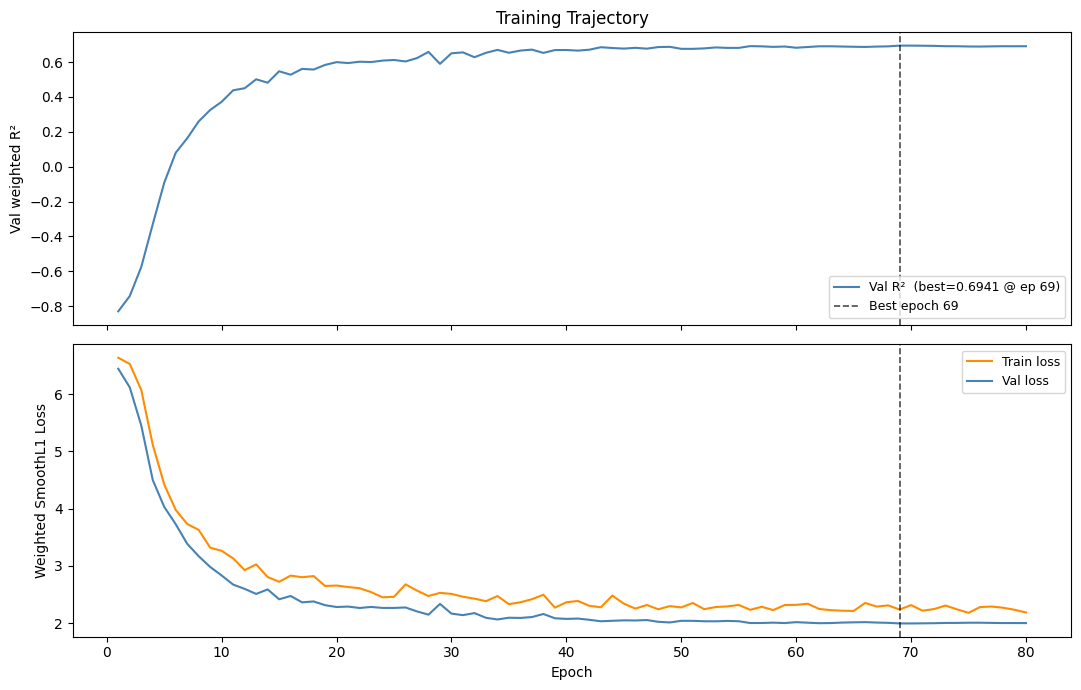


Best val R² = 0.6941 at epoch 69


In [ ]:
import matplotlib.pyplot as plt

epochs_axis = list(range(1, len(history["val_r2"]) + 1))
best_r2_epoch = int(np.argmax(history["val_r2"])) + 1
best_r2_val = max(history["val_r2"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(epochs_axis, history["val_r2"], color="steelblue", linewidth=1.5,
         label=f"Val R²  (best={best_r2_val:.4f} @ ep {best_r2_epoch})")
ax1.axvline(best_r2_epoch, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
            label=f"Best epoch {best_r2_epoch}")
ax1.set_ylabel("Val weighted R²")
ax1.set_title("Training Trajectory")
ax1.legend(loc="lower right", fontsize=9)

ax2.plot(epochs_axis, history["train_loss"], color="darkorange", linewidth=1.5, label="Train loss")
ax2.plot(epochs_axis, history["val_loss"],   color="steelblue",  linewidth=1.5, label="Val loss")
ax2.axvline(best_r2_epoch, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Weighted SmoothL1 Loss")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nBest val R² = {best_r2_val:.4f} at epoch {best_r2_epoch}")

## 16. Final Validation Metrics
Evaluate best checkpoint on the entire validation set and print global R² and per-target RMSE.

In [ ]:
model.eval()
with torch.no_grad():
    val_preds = model(
        torch.tensor(X_val, dtype=torch.float32, device=device)
    ).cpu().numpy()

val_r2_best = weighted_global_r2(Y_val_raw, val_preds)
val_rmse_best = rmse_per_target(Y_val_raw, val_preds)

print("=" * 55)
print(f"Final val weighted R²: {val_r2_best:.4f}  (best epoch {best_epoch})")
print("=" * 55)
print("RMSE per target:")
for t, v in val_rmse_best.items():
    print(f"  {t:<18}: {v:.4f}")
print("=" * 55)

if val_r2_best < 0.65:
    print(
        "\n val R² = {:.4f} is way below baseline (~0.74).".format(val_r2_best)
    )
else:
    print(f"\n  R² = {val_r2_best:.4f} - consistent with baseline (~0.74). OK.")

Final val weighted R²: 0.6941  (best epoch 69)
RMSE per target:
  Dry_Green_g       : 16.3901
  Dry_Dead_g        : 11.0100
  Dry_Clover_g      : 10.4349
  GDM_g             : 14.9694
  Dry_Total_g       : 16.1970

  *** WARNING: val R² = 0.6941 is below expected baseline (~0.80).


## 17. Test Inference
Load best checkpoint, encode test features through encoder+head, inverse-scale predictions.

In [16]:
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    test_preds = model(X_test_t).cpu().numpy()

test_preds = np.clip(test_preds, 0.0, None)

print(f"test_preds shape: {test_preds.shape}")
print(f"test_preds range: [{test_preds.min():.2f}, {test_preds.max():.2f}]")
print("Sample predictions (first 3 test images):")
for i in range(min(3, len(test_image_ids))):
    print(f"  {test_image_ids[i]}: {dict(zip(TARGETS, test_preds[i].round(2)))}")

test_preds shape: (1, 5)
test_preds range: [3.08, 59.70]
Sample predictions (first 3 test images):
  ID1001187975: {'Dry_Green_g': np.float32(34.08), 'Dry_Dead_g': np.float32(14.65), 'Dry_Clover_g': np.float32(3.08), 'GDM_g': np.float32(40.13), 'Dry_Total_g': np.float32(59.7)}


## 18. Format Predictions as Submission CSV
Map (image_id, 5 targets) → long-format rows matching test.csv sample_id keys.

In [ ]:
def prepare_submission(test_csv_path, predictions, image_ids):
    """Returns long-format DataFrame with columns [sample_id, target]."""
    df_t = pd.read_csv(test_csv_path)

    pred_dict = {
        img_id: {col: float(val) for col, val in zip(TARGETS, pred_row)}
        for img_id, pred_row in zip(image_ids, predictions)
    }

    def _get_pred(row):
        img_id = row["sample_id"].split("__")[0]
        target_name = row["target_name"]
        val = pred_dict.get(img_id, {}).get(target_name, 0.0)
        return max(0.0, val)

    df_t["target"] = df_t.apply(_get_pred, axis=1)
    return df_t[["sample_id", "target"]]


submission = prepare_submission(TEST_CSV, test_preds, test_image_ids)

out_path = os.path.join(cfg.output_dir, "submission.csv")
submission.to_csv(out_path, index=False)

print(f"Submission saved to: {out_path}")
print(f"Rows: {len(submission)}")
print(submission.head(10))
print("\nTarget value stats:")
print(submission["target"].describe().round(3))
print("\nWorking dir:", os.listdir(cfg.output_dir))

Submission saved to: /kaggle/working/submission.csv
Rows: 5
                    sample_id     target
0  ID1001187975__Dry_Clover_g   3.084476
1    ID1001187975__Dry_Dead_g  14.647679
2   ID1001187975__Dry_Green_g  34.081169
3   ID1001187975__Dry_Total_g  59.695065
4         ID1001187975__GDM_g  40.134727

Target value stats:
count     5.000
mean     30.329
std      22.140
min       3.084
25%      14.648
50%      34.081
75%      40.135
max      59.695
Name: target, dtype: float64

Working dir: ['.virtual_documents', 'submission.csv']
